# Import necessary libraries

In [18]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import LineString
import utm
import math

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow import keras
from tensorflow.keras import layers, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow import keras
from tensorflow.keras import layers, optimizers
from sklearn.base import BaseEstimator, RegressorMixin

# Remove warning 

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Read Dataset

In [3]:
Data_folder = 'Dataset'

# Read  data
data_files = [os.path.join(Data_folder, file) for file in os.listdir(Data_folder) if file.endswith('.csv')]
df = pd.concat([pd.read_csv(file) for file in data_files], ignore_index=True)

In [4]:
df.shape

(77536, 186)

# Feature Selection

In [5]:
features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder','OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

In [6]:
df=df[features]

# Remove duplicate data points

In [7]:
# Remove duplicate rows and get the original DataFrame without duplicates
df_without_duplicates = df.drop_duplicates()
df=df_without_duplicates
df.shape

(71522, 11)

# Convert time string to seconds function

In [8]:
def time_to_seconds(time_str):
    # Split the time string by space
    time_parts = time_str.split()
    
    # Extract minutes and seconds
    minutes = float(time_parts[0][:-1])  # Remove 'm' and convert to float
    seconds = float(time_parts[1][:-1])  # Remove 's' and convert to float
    
    # Convert to seconds
    total_seconds = (minutes * 60) + seconds
    return total_seconds

# Preprocess 'OSD.flyTime' column
df['OSD.flyTime'] = df['OSD.flyTime'].apply(time_to_seconds)


# Convert latitude and longitude into Cartesian coordinates

In [9]:
import pandas as pd
import math

# Define a function to convert latitude and longitude to local Cartesian coordinates
def convert_to_cartesian(row, origin_lat, origin_lon):
    # Calculate the differences between the current point and the origin
    delta_lat = row['OSD.latitude'] - origin_lat
    delta_lon = row['OSD.longitude'] - origin_lon
    
    # Convert the differences to meters using an appropriate conversion factor
    # For simplicity, assuming 1 degree of latitude = 111.32 km and 1 degree of longitude = 111.32 km * cos(latitude)
    lat_to_m = 111320.0  # meters per degree of latitude at the equator
    lon_to_m = 111320.0 * abs(math.cos(math.radians(origin_lat)))  # meters per degree of longitude
    
    # Calculate the x and y coordinates in meters
    x = delta_lon * lon_to_m
    y = delta_lat * lat_to_m
    
    return pd.Series([x, y])  # Return a Series with two values

# Assume 'df' is your DataFrame with columns 'OSD.latitude' and 'OSD.longitude'
# Define your local projection origin point
origin_lat = df['OSD.latitude'].iloc[0]  # Latitude of the first point in the DataFrame
origin_lon = df['OSD.longitude'].iloc[0]  # Longitude of the first point in the DataFrame

# Apply the conversion function to each row and create new columns for local Cartesian coordinates
df[['local_x', 'local_y']] = df.apply(convert_to_cartesian, args=(origin_lat, origin_lon), axis=1)

# Scale the Cartesian coordinates between -1 and 1 using Min-Max scaling
df['OSD.latitude'] = 2 * (df['local_x'] - df['local_x'].min()) / (df['local_x'].max() - df['local_x'].min()) - 1
df['OSD.longitude'] = 2 * (df['local_y'] - df['local_y'].min()) / (df['local_y'].max() - df['local_y'].min()) - 1

# Drop the 'local_x' and 'local_y' columns
df.drop(columns=['local_x', 'local_y'], inplace=True)

# Print the DataFrame
df.head()


,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
0,0.0,1024,1024,1024,1024,0.999882,0.999001,0.0,5.7,2.5,113.9
1,0.1,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
2,0.2,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
3,0.3,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.0
4,0.4,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.1


# Data Cleaning

### Remove Null values

In [10]:
null_counts = df.isnull().sum(axis=0)
print(null_counts)

OSD.flyTime        0
RC.aileron         0
RC.elevator        0
RC.throttle        0
RC.rudder          0
OSD.longitude      0
OSD.latitude       0
OSD.height [ft]    0
OSD.pitch          0
OSD.roll           0
OSD.yaw            0
dtype: int64


## Identify Outliers

# Handle the Outliers

In [11]:
def two_sided_median_filter(data, window_size):
    """
    Perform two-sided median filtering for outlier detection.

    Parameters:
    - data: 1D numpy array containing the flight data
    - window_size: Size of the window for median filtering

    Returns:
    - filtered_data: Numpy array with outliers replaced by the median value of neighboring elements
    """
    filtered_data = np.zeros_like(data)
    half_window = window_size // 2

    for i in range(len(data)):
        lower_bound = max(0, i - half_window)
        upper_bound = min(len(data), i + half_window + 1)

        window = data[lower_bound:upper_bound]
        if len(window) > 0:  # Check if window is not empty
            median = np.median(window)

            if data[i] < median - 1.5 * np.median(np.abs(window - median)):
                filtered_data[i] = median
            elif data[i] > median + 1.5 * np.median(np.abs(window - median)):
                filtered_data[i] = median
            else:
                filtered_data[i] = data[i]
        else:
            # If window is empty, set the filtered value to the original value
            filtered_data[i] = data[i]

    return filtered_data


# Apply two-sided median filtering to each feature
window_size = 7  # You can adjust the window size as needed
for feature in features:
    df[feature + '_filtered'] = two_sided_median_filter(df[feature].values, window_size)
    
# Calculate residuals
residuals = np.abs(df[feature] - df[feature + '_filtered'])

# Define threshold (e.g., based on median absolute deviation)
median_absolute_deviation = np.median(residuals)
threshold = 3 * median_absolute_deviation  # Adjust multiplier as needed

# Identify outliers
outliers = df[residuals > threshold]

# Filter outliers
filtered_df = df[residuals <= threshold]

# Display the shape of the filtered DataFrame before and after removing outliers
print("Shape of original DataFrame:", df.shape)
print("Shape of filtered DataFrame (after removing outliers):", filtered_df.shape)

Shape of original DataFrame: (71522, 22)
Shape of filtered DataFrame (after removing outliers): (64356, 22)


In [12]:
df=filtered_df
df=df[features]
df

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
1,0.1,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
2,0.2,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
3,0.3,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.0
4,0.4,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.1
5,0.5,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.1
...,...,...,...,...,...,...,...,...,...,...,...
77530,931.0,1024,1024,364,1024,-0.998428,-0.990589,1.9,6.2,-3.7,42.7
77531,931.1,1024,1024,364,1024,-0.998428,-0.990589,1.9,6.0,-3.7,42.4
77532,931.2,1024,1024,364,1024,-0.998427,-0.990588,1.9,5.3,-3.6,42.0
77533,931.3,1024,1024,364,1024,-0.998427,-0.990588,1.9,4.8,-1.5,41.5


# Normalize other features

In [13]:
# Instantiate the StandardScaler
scaler = StandardScaler()

# Define the columns to normalize
columns_to_normalize = ['OSD.flyTime','RC.aileron','RC.elevator','RC.throttle','RC.rudder','OSD.longitude','OSD.latitude','OSD.height [ft]','OSD.pitch','OSD.roll','OSD.yaw']

# Apply StandardScaler to the specified columns
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])
df.head()

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
1,-1.459063,0.035987,-0.524142,0.128677,-0.018592,5.436911,5.434930,-0.573543,1.215106,1.40385,1.195496
2,-1.458700,0.035987,-0.524142,0.128677,-0.018592,5.436910,5.434931,-0.573543,1.215106,1.40385,1.195496
3,-1.458337,0.035987,-0.524142,0.128677,-0.018592,5.436910,5.434931,-0.573543,1.215106,1.40385,1.195496
4,-1.457975,0.035987,-0.524142,0.128677,-0.018592,5.436909,5.434930,-0.573543,1.215106,1.40385,1.196584
5,-1.457612,0.035987,-0.524142,0.128677,-0.018592,5.436909,5.434931,-0.573543,1.215106,1.40385,1.196584


Fitting 3 folds for each of 10 candidates, totalling 30 fits
537/537 [==============================] - 1s 2ms/step
[CV] END batch_size=64, dropout_rate=0.5, epochs=50, layers=2, learning_rate=0.0001, neurons=32; total time= 1.2min
537/537 [==============================] - 1s 2ms/step
[CV] END batch_size=64, dropout_rate=0.5, epochs=50, layers=2, learning_rate=0.0001, neurons=32; total time= 1.2min
537/537 [==============================] - 1s 2ms/step
[CV] END batch_size=64, dropout_rate=0.5, epochs=50, layers=2, learning_rate=0.0001, neurons=32; total time= 1.3min
537/537 [==============================] - 1s 1ms/step
[CV] END batch_size=32, dropout_rate=0.3, epochs=100, layers=1, learning_rate=0.001, neurons=64; total time= 3.9min
537/537 [==============================] - 1s 1ms/step
[CV] END batch_size=32, dropout_rate=0.3, epochs=100, layers=1, learning_rate=0.001, neurons=64; total time= 3.7min
537/537 [==============================] - 1s 2ms/step
[CV] END batch_size=32, dropo

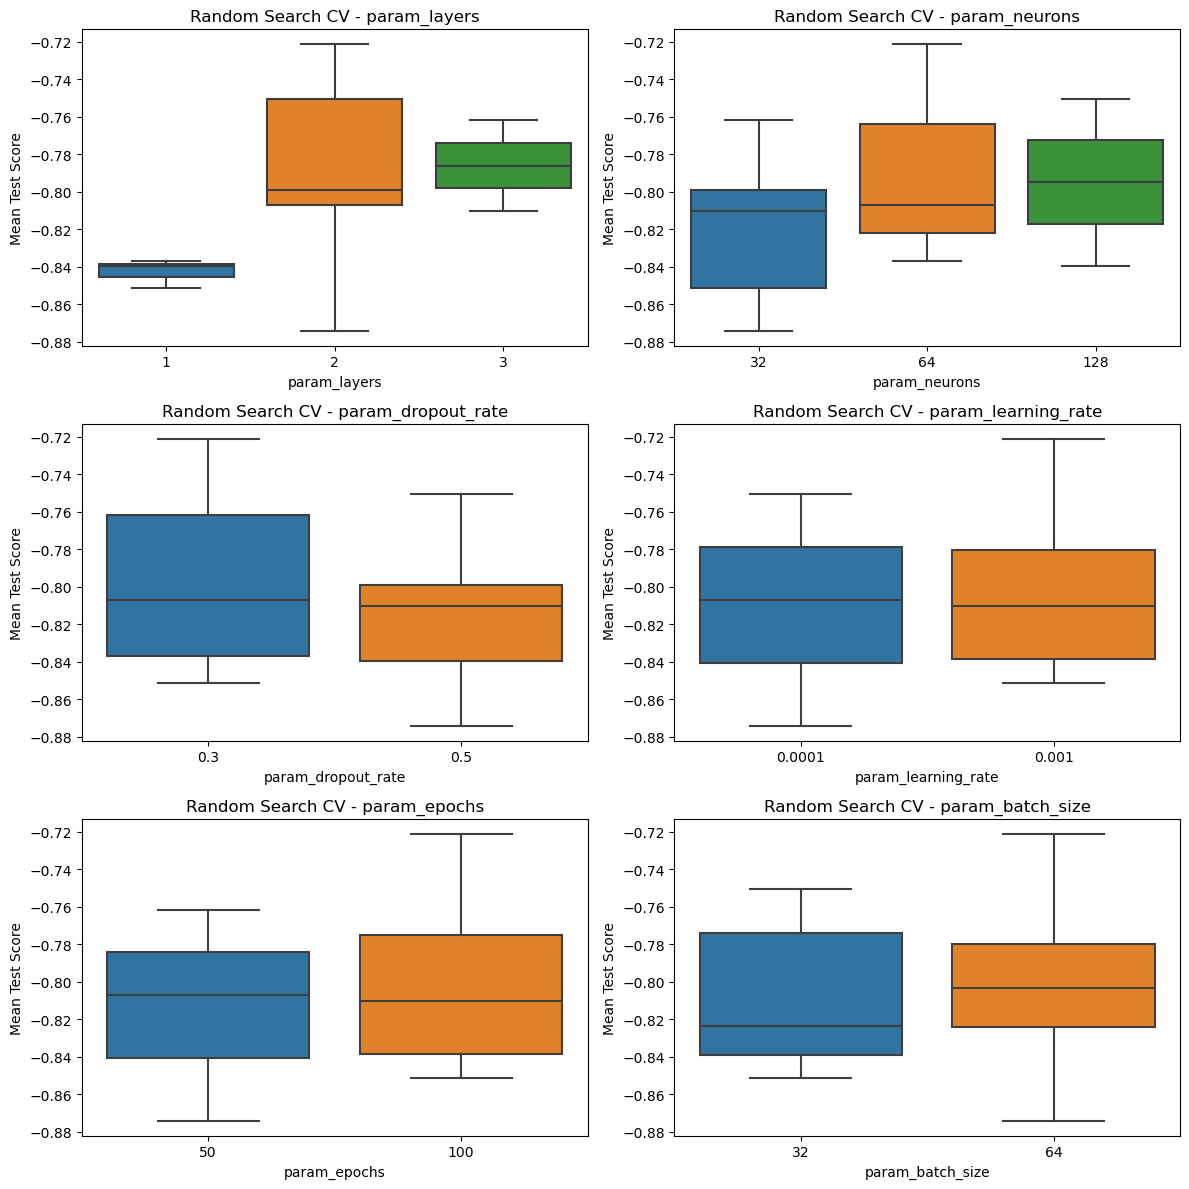

In [19]:
# Selecting relevant features and target variables
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into features and target variables
X = df[input_features]
y = df[output_targets]


# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define a wrapper class for KerasRegressor
class KerasRegressorWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, layers=1, neurons=64, dropout_rate=0.3, learning_rate=0.001, epochs=100, batch_size=32):
        self.layers = layers
        self.neurons = neurons
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.model = None

    def create_model(self):
        model = keras.Sequential()
        model.add(layers.Dense(self.neurons, activation='relu', input_shape=(X_train.shape[1],)))
        model.add(layers.Dropout(self.dropout_rate))
        for _ in range(self.layers - 1):
            model.add(layers.Dense(self.neurons, activation='relu'))
            model.add(layers.Dropout(self.dropout_rate))
        model.add(layers.Dense(len(output_targets)))
        optimizer = optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(optimizer=optimizer, loss='mean_squared_error')
        return model

    def fit(self, X, y):
        self.model = self.create_model()
        self.model.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, verbose=0)
        return self

    def predict(self, X):
        return self.model.predict(X)

# Define hyperparameters to tune
param_dist = {
    'layers': [1, 2, 3], # number of hidden layers
    'neurons': [32, 64, 128], # number of neurons per layer
    'dropout_rate': [0.3, 0.5], # dropout rate
    'learning_rate': [0.001, 0.0001], # learning rate
    'epochs': [50, 100], # number of training epochs
    'batch_size': [32, 64] # batch size
}

# Create KerasRegressor wrapper
model = KerasRegressorWrapper()

# Perform random search
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=10, scoring='neg_mean_squared_error', cv=3, verbose=2, random_state=42, n_jobs=1)

random_search.fit(X_train, y_train)

# Print best parameters and best score
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

# Extract results from random search
results = pd.DataFrame(random_search.cv_results_)

# Define hyperparameters to plot
hyperparameters = ['param_layers', 'param_neurons', 'param_dropout_rate', 'param_learning_rate',
                   'param_epochs', 'param_batch_size']

# Plot random search results
plt.figure(figsize=(12, 12))
for i, param in enumerate(hyperparameters):
    plt.subplot(3, 2, i+1)
    sns.boxplot(x=param, y='mean_test_score', data=results, ax=plt.gca())
    plt.title(f'Random Search CV - {param}')
    plt.xlabel(param)
    plt.ylabel('Mean Test Score')
plt.tight_layout()
plt.show()


In [20]:
# Selecting relevant features and target variables
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into features and target variables
X = df[input_features]
y = df[output_targets]

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build the model using best parameters
model = keras.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(layers.Dropout(0.3))
for _ in range(2):
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.3))
model.add(layers.Dense(len(output_targets)))

# Compile the model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_split=0.2, verbose=1)

# Evaluate the model
mse = model.evaluate(X_test, y_test, verbose=0)
print("Test Mean Squared Error:", mse)


Epoch 1/100
644/644 [==============================] - 4s 4ms/step - loss: 0.9114 - val_loss: 0.8770
Epoch 2/100
644/644 [==============================] - 3s 4ms/step - loss: 0.8695 - val_loss: 0.8547
Epoch 3/100
644/644 [==============================] - 2s 4ms/step - loss: 0.8472 - val_loss: 0.8318
Epoch 4/100
644/644 [==============================] - 2s 4ms/step - loss: 0.8316 - val_loss: 0.8078
Epoch 5/100
644/644 [==============================] - 2s 4ms/step - loss: 0.8159 - val_loss: 0.7982
Epoch 6/100
644/644 [==============================] - 2s 4ms/step - loss: 0.8074 - val_loss: 0.7890
Epoch 7/100
644/644 [==============================] - 2s 4ms/step - loss: 0.8019 - val_loss: 0.7841
Epoch 8/100
644/644 [==============================] - 2s 4ms/step - loss: 0.7980 - val_loss: 0.7808
Epoch 9/100
644/644 [==============================] - 2s 3ms/step - loss: 0.7926 - val_loss: 0.7712
Epoch 10/100
644/644 [==============================] - 2s 3ms/step - loss: 0.7893 - val_lo

644/644 [==============================] - 3s 4ms/step - loss: 0.7415 - val_loss: 0.7314
Epoch 82/100
644/644 [==============================] - 3s 4ms/step - loss: 0.7479 - val_loss: 0.7393
Epoch 83/100
644/644 [==============================] - 3s 4ms/step - loss: 0.7425 - val_loss: 0.7319
Epoch 84/100
644/644 [==============================] - 3s 4ms/step - loss: 0.7403 - val_loss: 0.7301
Epoch 85/100
644/644 [==============================] - 2s 4ms/step - loss: 0.7438 - val_loss: 0.7306
Epoch 86/100
644/644 [==============================] - 3s 4ms/step - loss: 0.7430 - val_loss: 0.7291
Epoch 87/100
644/644 [==============================] - 2s 4ms/step - loss: 0.7425 - val_loss: 0.7291
Epoch 88/100
644/644 [==============================] - 3s 5ms/step - loss: 0.7427 - val_loss: 0.7312
Epoch 89/100
644/644 [==============================] - 3s 4ms/step - loss: 0.7420 - val_loss: 0.7328
Epoch 90/100
644/644 [==============================] - 3s 5ms/step - loss: 0.7427 - val_loss: 

31/31 [==============================] - 0s 2ms/step
OSD.longitude - Mean Squared Error: 8.98, R-squared: -15.71%, Mean Absolute Error: 2.20, Variance Explained: -15.71%
OSD.latitude - Mean Squared Error: 10.29, R-squared: -260.19%, Mean Absolute Error: 2.65, Variance Explained: -260.19%
OSD.height [ft] - Mean Squared Error: 2.85, R-squared: -392.66%, Mean Absolute Error: 1.60, Variance Explained: -392.66%
OSD.pitch - Mean Squared Error: 5.72, R-squared: -13.29%, Mean Absolute Error: 1.67, Variance Explained: -13.29%
OSD.roll - Mean Squared Error: 0.92, R-squared: -6.51%, Mean Absolute Error: 0.80, Variance Explained: -6.51%
OSD.yaw - Mean Squared Error: 9213.96, R-squared: -18.33%, Mean Absolute Error: 82.60, Variance Explained: -18.33%


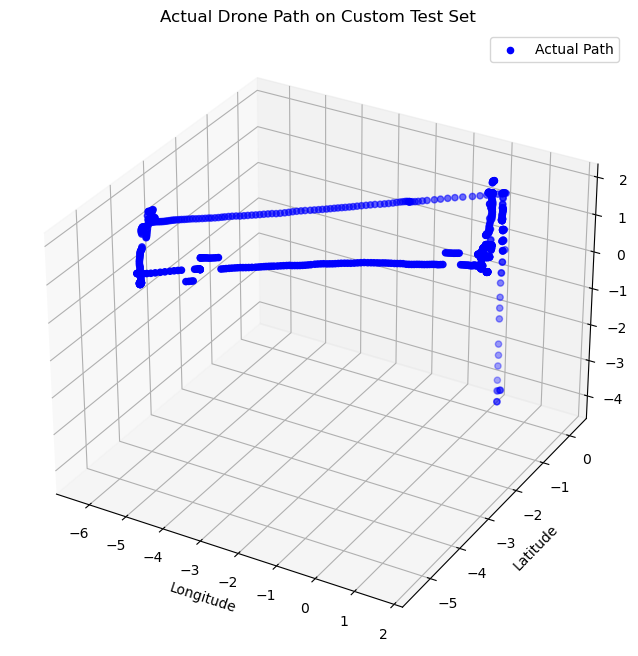

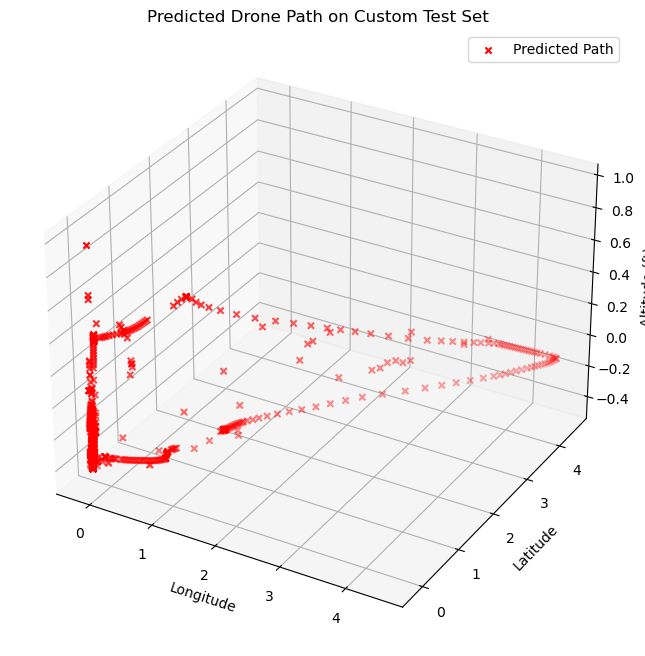

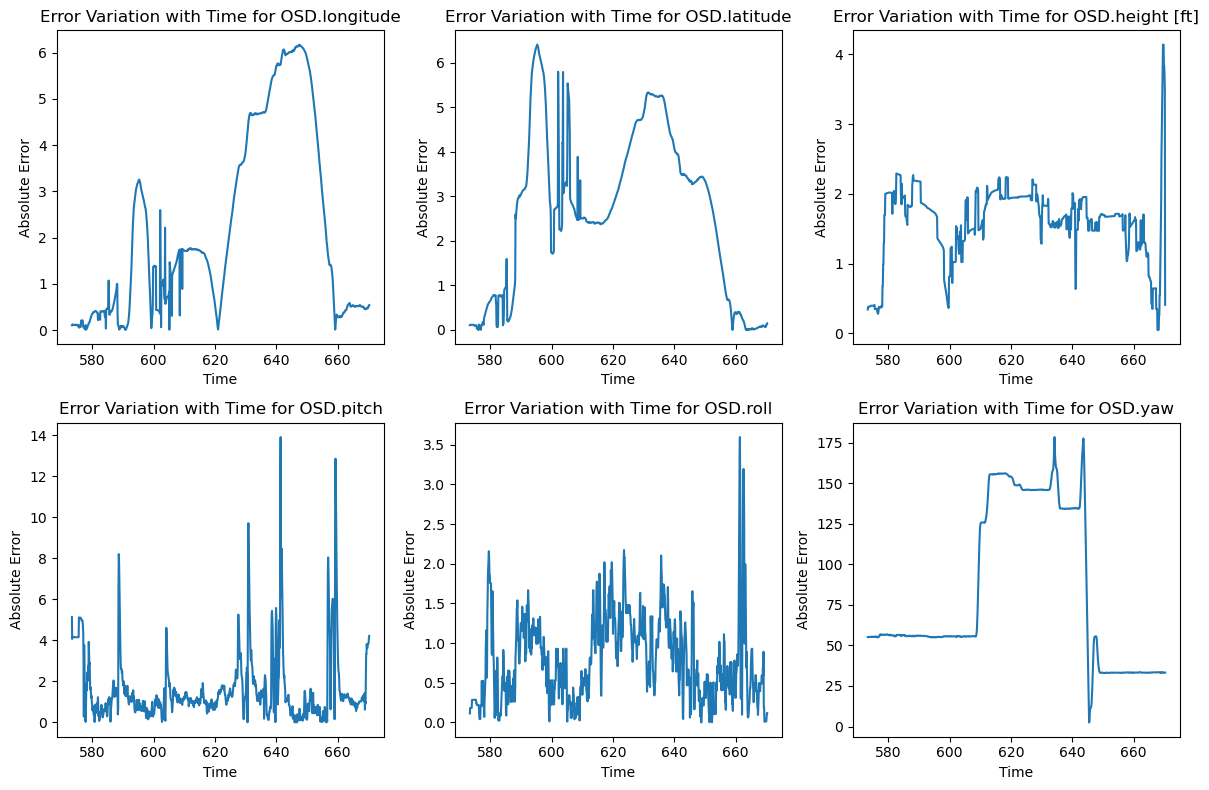

Average Percentage Accuracy (Variance Explained) across all target variables: -117.78%


In [37]:
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Read the custom test dataset
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Preprocess 'OSD.flyTime' column in the test dataset
df_test_custom['OSD.flyTime'] = df_test_custom['OSD.flyTime'].apply(time_to_seconds)

# Define your local projection origin point
origin_lat = df_test_custom['OSD.latitude'].iloc[0]  # Latitude of the first point in the DataFrame
origin_lon = df_test_custom['OSD.longitude'].iloc[0]  # Longitude of the first point in the DataFrame

# Apply the conversion function to each row and create new columns for local Cartesian coordinates
df_test_custom[['local_x', 'local_y']] = df_test_custom.apply(convert_to_cartesian, args=(origin_lat, origin_lon), axis=1)

# Keep the latitude and longitude columns and replace their values with 'local_x' and 'local_y' respectively
df_test_custom['OSD.latitude'] = df_test_custom['local_x']
df_test_custom['OSD.longitude'] = df_test_custom['local_y']

# Drop the 'local_x' and 'local_y' columns if needed
df_test_custom.drop(columns=['local_x', 'local_y'], inplace=True)


features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder','OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']
df_test_custom=df_test_custom[features]

# Normalization using StandardScaler
scaler = StandardScaler()
df_test_custom_scaled = scaler.fit_transform(df_test_custom)

X_test_custom_scaled = df_test_custom_scaled[:, :5]  # Select the first 5 columns after scaling

# Make predictions on the custom test set
y_pred_custom = model.predict(X_test_custom_scaled)

# Calculate and display accuracy metrics for each target variable on the custom test set
for i, target_variable in enumerate(output_targets):
    mse_custom = mean_squared_error(df_test_custom[target_variable], y_pred_custom[:, i])
    r2_custom = r2_score(df_test_custom[target_variable], y_pred_custom[:, i])
    mae_custom = mean_absolute_error(df_test_custom[target_variable], y_pred_custom[:, i])
    variance_explained_custom = 100 * (1 - mse_custom / np.var(df_test_custom[target_variable]))
    
    print(f'{target_variable} - Mean Squared Error: {mse_custom:.2f}, R-squared: {r2_custom:.2%}, Mean Absolute Error: {mae_custom:.2f}, Variance Explained: {variance_explained_custom:.2f}%')


# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.height [ft]'], c='blue', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()

# Create a 3D plot for the predicted drone path on custom test set
fig_predicted_custom = plt.figure(figsize=(12, 8))
ax_predicted_custom = fig_predicted_custom.add_subplot(111, projection='3d')
ax_predicted_custom.scatter(y_pred_custom[:, 0], y_pred_custom[:, 1], y_pred_custom[:, 2], c='red', marker='x', label='Predicted Path')
ax_predicted_custom.set_xlabel('Longitude')
ax_predicted_custom.set_ylabel('Latitude')
ax_predicted_custom.set_zlabel('Altitude (ft)')
ax_predicted_custom.set_title('Predicted Drone Path on Custom Test Set')
ax_predicted_custom.legend()

# Calculate absolute error for each target variable
absolute_errors = np.abs(df_test_custom[output_targets] - y_pred_custom)

# Calculate absolute error for each target variable
absolute_errors = np.abs(df_test_custom[output_targets] - y_pred_custom)

# Plot error variation with time for each target variable
plt.figure(figsize=(12, 8))
for i, target_variable in enumerate(output_targets):
    plt.subplot(2, 3, i+1)
    plt.plot(df_test_custom['OSD.flyTime'], absolute_errors[target_variable])
    plt.title(f'Error Variation with Time for {target_variable}')
    plt.xlabel('Time')
    plt.ylabel('Absolute Error')
plt.tight_layout()

# Show the actual and predicted path plots on the custom test set
plt.show()

# Calculate the variance explained for each target variable
variance_explained = [100 * (1 - mean_squared_error(df_test_custom[target_variable], y_pred_custom[:, i]) / np.var(df_test_custom[target_variable])) for i, target_variable in enumerate(output_targets)]

# Calculate the average variance explained across all target variables
average_variance_explained = np.mean(variance_explained)

print(f"Average Percentage Accuracy (Variance Explained) across all target variables: {average_variance_explained:.2f}%")

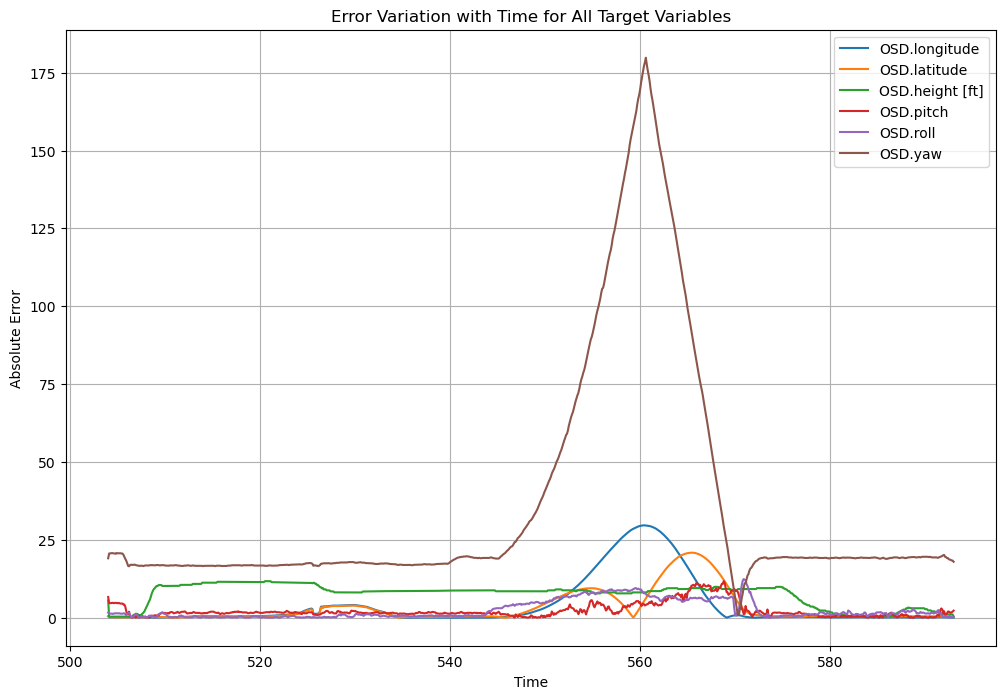

In [33]:
plt.figure(figsize=(12, 8))
for target_variable in output_targets:
    plt.plot(df_test_custom['OSD.flyTime'], absolute_errors[target_variable], label=target_variable)

plt.title('Error Variation with Time for All Target Variables')
plt.xlabel('Time')
plt.ylabel('Absolute Error')
plt.legend()
plt.grid(True)
plt.show()